In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Componentes
compounds = pd.read_csv('screened_compounds_rel_8.5.csv')

print(compounds.shape)
print(compounds.head())

print(compounds.columns.tolist())

(621, 6)
   DRUG_ID SCREENING_SITE   DRUG_NAME  \
0        1            MGH   Erlotinib   
1        3            MGH   Rapamycin   
2        5            MGH   Sunitinib   
3        6            MGH  PHA-665752   
4        9            MGH      MG-132   

                                            SYNONYMS  \
0  Tarceva, RG-1415, CP-358774, OSI-774, Ro-50823...   
1  AY-22989, Sirolimus, WY-090217, Torisel, Rapamune   
2                 Sutent, Sunitinib Malate, SU-11248   
3                              PHA665752, PHA 665752   
4                             LLL cpd, MG 132, MG132   

                                TARGET                     TARGET_PATHWAY  
0                                 EGFR                     EGFR signaling  
1                               MTORC1                PI3K/MTOR signaling  
2  PDGFR, KIT, VEGFR, FLT3, RET, CSF1R                      RTK signaling  
3                                  MET                      RTK signaling  
4                    Protea

In [3]:
# GDSC2 IC50
ic50 = pd.read_excel('GDSC2_fitted_dose_response_27Oct23.xlsx')

print(ic50.shape)
print(ic50.head(5))
print(ic50.tail(5))
print(ic50.columns.tolist())

print(ic50['DRUG_ID'].nunique())

(242036, 16)
  DATASET  NLME_RESULT_ID  NLME_CURVE_ID CELL_LINE_NAME SANGER_MODEL_ID  \
0   GDSC2             343       15946310         PFSK-1       SIDM01132   
1   GDSC2             343       15946548           A673       SIDM00848   
2   GDSC2             343       15946830            ES5       SIDM00263   
3   GDSC2             343       15947087            ES7       SIDM00269   
4   GDSC2             343       15947369          EW-11       SIDM00203   

           CANCER_TYPE  DRUG_ID     DRUG_NAME PUTATIVE_TARGET  \
0  Other Solid Cancers     1003  Camptothecin            TOP1   
1      Ewing's Sarcoma     1003  Camptothecin            TOP1   
2      Ewing's Sarcoma     1003  Camptothecin            TOP1   
3      Ewing's Sarcoma     1003  Camptothecin            TOP1   
4      Ewing's Sarcoma     1003  Camptothecin            TOP1   

      PATHWAY_NAME  MIN_CONC  MAX_CONC   LN_IC50       AUC      RMSE   Z_SCORE  
0  DNA replication    0.0001       0.1 -1.463887  0.930220  0.08

In [4]:
ic50_selu = ic50[ic50['DRUG_NAME'] == 'Selumetinib']
print(ic50_selu.shape)

# Buscar un SIDM que esté duplicado y ver qué diferencia hay entre sus filas
sidm_duplicado = ic50_selu[ic50_selu.duplicated(subset='SANGER_MODEL_ID', keep=False)]

print(ic50_selu['SANGER_MODEL_ID'].nunique())
print(ic50_selu['DRUG_ID'].nunique())

# Cuántos SIDMs únicos tiene cada DRUG_ID
print(ic50_selu.groupby('DRUG_ID')['SANGER_MODEL_ID'].nunique())

# Verificar si dentro de un mismo DRUG_ID hay SIDMs repetidos
for drug_id in ic50_selu['DRUG_ID'].unique():
    subset = ic50_selu[ic50_selu['DRUG_ID'] == drug_id]
    duplicados = subset['SANGER_MODEL_ID'].duplicated().sum()
    print(f"DRUG_ID {drug_id}: {len(subset)} filas, {subset['SANGER_MODEL_ID'].nunique()} únicos, {duplicados} duplicados internos")

(1666, 16)
967
2
DRUG_ID
1062    949
1736    717
Name: SANGER_MODEL_ID, dtype: int64
DRUG_ID 1062: 949 filas, 949 únicos, 0 duplicados internos
DRUG_ID 1736: 717 filas, 717 únicos, 0 duplicados internos


In [21]:
# Habia dos versiones de Selumetinib (por eso este tiene 2 DRUG_IDs), 
# supongo debido a nueva formulación o lotes distintos. 

# Para evitar confusión, me quedo solo con el DRUG_ID = 1062 que es el que tiene más filas únicas (más SIDMs)
drug_data = ic50_selu[ic50_selu['DRUG_ID'] == 1062][['SANGER_MODEL_ID', 'CELL_LINE_NAME', 'CANCER_TYPE', 'LN_IC50', 'AUC', 'Z_SCORE']].reset_index(drop=True)
print(f"Filas finales: {len(drug_data)}")
print(f"SIDM únicos: {drug_data['SANGER_MODEL_ID'].nunique()}")
print(drug_data.head())

Filas finales: 949
SIDM únicos: 949
  SANGER_MODEL_ID CELL_LINE_NAME      CANCER_TYPE   LN_IC50       AUC  \
0       SIDM00848           A673  Ewing's Sarcoma  3.928347  0.963347   
1       SIDM00263            ES5  Ewing's Sarcoma  4.440490  0.975295   
2       SIDM00269            ES7  Ewing's Sarcoma  4.920850  0.983715   
3       SIDM00203          EW-11  Ewing's Sarcoma  5.711606  0.983322   
4       SIDM01111        SK-ES-1  Ewing's Sarcoma  4.748656  0.986709   

    Z_SCORE  
0  0.350088  
1  0.642112  
2  0.916013  
3  1.366902  
4  0.817828  


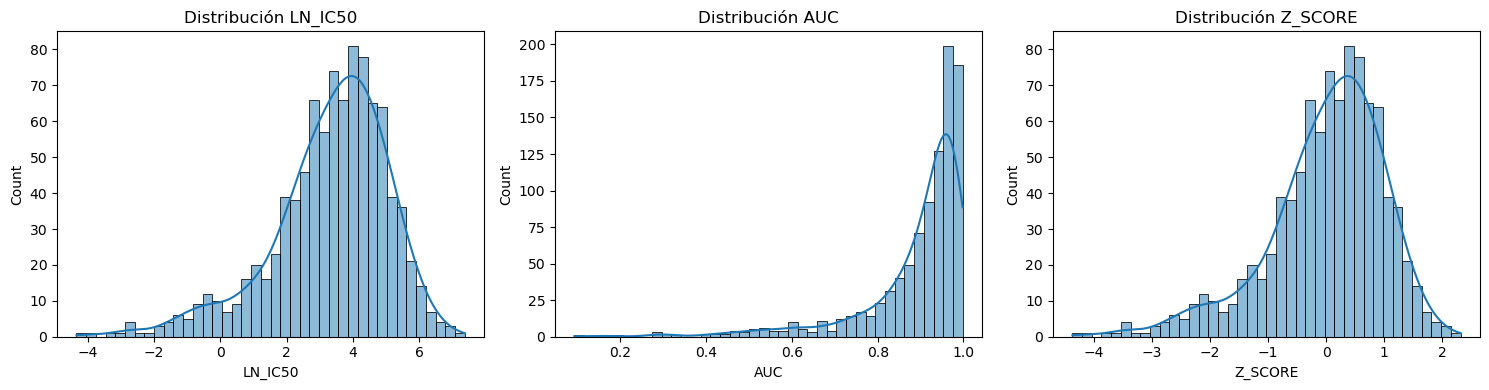

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(drug_data['LN_IC50'], ax=axes[0], bins=40, kde=True)
axes[0].set_title('Distribución LN_IC50')

sns.histplot(drug_data['AUC'], ax=axes[1], bins=40, kde=True)
axes[1].set_title('Distribución AUC')

sns.histplot(drug_data['Z_SCORE'], ax=axes[2], bins=40, kde=True)
axes[2].set_title('Distribución Z_SCORE')

plt.tight_layout()
plt.show()

# A partir de esto veo que las distribuciones de LN_IC50 y Z_SCORE son similares. 
# En cambio, AUC esta sesgada hacía 1. 
# Por lo tanto, para el modelo de predicción, me quedo con LN_IC50 como variable objetivo 
# dado que tiene mayor rango.

In [9]:
# Como el archivo es pesado, miro solo las primeras filas para entender la estructura
rna = pd.read_csv("rnaseq_merged_rsem_tpm_20260323.csv", nrows=5)
print(rna.shape)
print(rna.head())
print(rna.columns.tolist()[:10])  # Solo primeras 10 columnas

(5, 1901)
      model_id       Unnamed: 1 Unnamed: 2 SIDM00001 SIDM00002 SIDM00003  \
0   model_name              NaN        NaN     MEC-1   NBsusSR       M14   
1  data_source              NaN        NaN     Broad    Sanger    Sanger   
2  gene_symbol  ensembl_gene_id    gene_id       NaN       NaN       NaN   
3         A1BG  ENSG00000121410  SIDG00001     3.853    4.5059    3.9736   
4     A1BG-AS1  ENSG00000268895  SIDG00002    1.8156    2.3868    3.1408   

       SIDM00005 SIDM00006 SIDM00007 SIDM00008  ...      SIDM02262  \
0  MDA-MB-134-VI     MCC26     MCC13      MCAS  ...  WTSI-COLO_427   
1          Broad    Sanger    Sanger     Broad  ...         Sanger   
2            NaN       NaN       NaN       NaN  ...            NaN   
3         5.7038    3.9069    6.1198    0.0566  ...         0.1635   
4         3.3334    2.5801    3.5336    0.0976  ...              0   

       SIDM02263      SIDM02264        SIDM02265        SIDM02266  \
0  WTSI-COLO_425  WTSI-COLO_061  WTSI-COLIV

In [11]:
# Como las columnas 1 y 2 son metadatos, reestructuro la tabla.

# obtengo los nombres del sidm
sidm_ids = pd.read_csv("rnaseq_merged_rsem_tpm_20260323.csv", nrows=1, header=None)
sidm_ids = sidm_ids.iloc[0, 3:].tolist()  # desde columna 3 en adelante

# solo cojo a partir de la fila 4 para extraer la expresión génica
rna = pd.read_csv("rnaseq_merged_rsem_tpm_20260323.csv", skiprows=3, index_col=0) 

rna = rna.iloc[:, 2:]        # solo valores de expresión

# transpongo para que filas = líneas celulares, columnas = genes
rna.columns = sidm_ids
rna = rna.T
rna.index.name = 'SANGER_MODEL_ID'

print(rna.shape)
print(rna.head()) 

# Verificar duplicados
print(f"Shape: {rna.shape}")
print(f"Columnas únicas: {rna.columns.is_unique}")
print(f"Índices únicos: {rna.index.is_unique}")

(1898, 41145)
gene_symbol        A1BG  A1BG-AS1    A1CF     A2M  A2M-AS1   A2ML1  A2ML1-AS1  \
SANGER_MODEL_ID                                                                 
SIDM00001        3.8530    1.8156  0.0000  0.2388   0.0000  0.0000        0.0   
SIDM00002        4.5059    2.3868  0.0286  0.5753   0.3448  0.4751        0.0   
SIDM00003        3.9736    3.1408  0.0144  4.1326   0.4114  0.0000        0.0   
SIDM00005        5.7038    3.3334  0.0566  0.5261   1.4489  0.4114        0.0   
SIDM00006        3.9069    2.5801  0.0426  5.6562   0.5656  0.1506        0.0   

gene_symbol      A2ML1-AS2   A2MP1  A3GALT2  ...    ZXDA    ZXDB    ZXDC  \
SANGER_MODEL_ID                              ...                           
SIDM00001              0.0  0.0000   0.0000  ...  0.7655  1.9561  2.8992   
SIDM00002              0.0  0.0144   0.1890  ...  1.7137  2.6803  5.6156   
SIDM00003              0.0  0.0000   0.0841  ...  1.0909  2.1010  4.0488   
SIDM00005              0.0  0.0426   0

In [14]:
genes_duplicados = rna.columns[rna.columns.duplicated(keep=False)]
print(f"Genes duplicados: {len(genes_duplicados)}")
print(genes_duplicados.unique())
#print(rna['VARS1']) #veo que hay un error de duplicado y por se repite el gen. Promedio para eliminar una.

rna = rna.T.groupby(level=0).mean().T
print(f"Shape final: {rna.shape}")
print(f"Columnas únicas: {rna.columns.is_unique}")

Genes duplicados: 2
Index(['VARS1'], dtype='object', name='gene_symbol')
gene_symbol       VARS1   VARS1
SANGER_MODEL_ID                
SIDM00001        6.0794  6.0794
SIDM00002        6.8089  6.8089
SIDM00003        6.1568  6.1568
SIDM00005        4.8104  4.8104
SIDM00006        6.4678  6.4678
...                 ...     ...
SIDM02267        3.9477  3.9477
SIDM02268        4.0117  4.0117
SIDM02269        3.2913  3.2913
SIDM02270        5.6259  5.6259
SIDM02271        3.8288  3.8288

[1898 rows x 2 columns]
Shape final: (1898, 41144)
Columnas únicas: True


In [27]:
# Líneas celulares en común
sidm_rna = set(rna.index)
sidm_drug = set(drug_data['SANGER_MODEL_ID'])

comunes = sidm_rna.intersection(sidm_drug)
print(f"Líneas en RNA-seq: {len(sidm_rna)}")
print(f"Líneas en Selumetinib: {len(sidm_drug)}")
print(f"Líneas en común: {len(comunes)}")

# Filtrar ambos datasets
rna_filtered = rna.loc[rna.index.isin(comunes)].sort_index() 
drug_filtered = drug_data[drug_data['SANGER_MODEL_ID'].isin(comunes)].set_index('SANGER_MODEL_ID').sort_index()

print(f"\nShape RNA filtrado: {rna_filtered.shape}")
print(f"Shape drug filtrado: {drug_filtered.shape}")

# Verificar que el orden es idéntico en ambos
print(f"\nÍndices alineados: {(rna_filtered.index == drug_filtered.index).all()}")

print(rna_filtered.head())


Líneas en RNA-seq: 1898
Líneas en Selumetinib: 949
Líneas en común: 925

Shape RNA filtrado: (925, 41144)
Shape drug filtrado: (925, 5)

Índices alineados: True
gene_symbol        A1BG  A1BG-AS1    A1CF     A2M  A2M-AS1   A2ML1  A2ML1-AS1  \
SANGER_MODEL_ID                                                                 
SIDM00023        0.1110    0.3785  0.2388  0.0286   0.1375  0.0144        0.0   
SIDM00040        0.0704    0.2016  0.0000  0.2016   0.0841  0.0000        0.0   
SIDM00041        4.8017    2.9126  0.0286  0.2141   1.7866  0.0286        0.0   
SIDM00042        0.5059    0.8639  0.0566  0.2265   1.3561  0.4542        0.0   
SIDM00043        0.1243    0.2016  0.0144  0.0000   0.1890  0.1890        0.0   

gene_symbol      A2ML1-AS2   A2MP1  A3GALT2  ...    ZXDA    ZXDB    ZXDC  \
SANGER_MODEL_ID                              ...                           
SIDM00023              0.0  0.0286   0.0841  ...  1.5705  2.6323  4.0108   
SIDM00040              0.0  0.0000   0.0000

In [28]:
print(drug_filtered.head())

                CELL_LINE_NAME                         CANCER_TYPE   LN_IC50  \
SANGER_MODEL_ID                                                                
SIDM00023                TE-12  Esophageal Squamous Cell Carcinoma  3.153004   
SIDM00040                TMK-1                   Gastric Carcinoma  2.020205   
SIDM00041             STS-0421                   Gastric Carcinoma  3.516299   
SIDM00042                  PL4                Pancreatic Carcinoma  1.773192   
SIDM00043               PCI-4B             Head and Neck Carcinoma  2.706349   

                      AUC   Z_SCORE  
SANGER_MODEL_ID                      
SIDM00023        0.882350 -0.092012  
SIDM00040        0.845988 -0.737933  
SIDM00041        0.939440  0.115139  
SIDM00042        0.808072 -0.878780  
SIDM00043        0.897443 -0.346694  


In [ ]:
# Dataset final 
X = rna_filtered
y = drug_filtered['LN_IC50']

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"¿NaN en X? {X.isna().any().any()}") 
print(f"¿NaN en y? {y.isna().any()}")

Shape X: (925, 41144)
Shape y: (925,)
¿NaN en X? True
¿NaN en y? False


In [ ]:
# Cuántos NaNs hay en total
total_nan = X.isna().sum().sum()
print(f"Total NaNs: {total_nan}")

# Cuántos genes tienen NaNs
genes_con_nan = X.isna().any().sum()
print(f"Genes con algún NaN: {genes_con_nan}")

# Cuántas líneas celulares tienen NaNs
lineas_con_nan = X.isna().any(axis=1).sum()
print(f"Líneas celulares con algún NaN: {lineas_con_nan}")

Total NaNs: 2627057
Genes con algún NaN: 4728
Líneas celulares con algún NaN: 925

Distribución de NaNs por gen:
count    4728.000000
mean      555.638113
std        87.302990
min       389.000000
25%       536.000000
50%       536.000000
75%       536.000000
max       925.000000
dtype: float64


In [36]:
X

gene_symbol,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,ZZZ3
SANGER_MODEL_ID,,,,,,,,,,,,,,,,,,,,,
SIDM00023,0.1110,0.3785,0.2388,0.0286,0.1375,0.0144,0.0000,0.0,0.0286,0.0841,...,1.5705,2.6323,4.0108,2.5435,0.0000,3.9439,5.7241,0.0,4.2525,4.5040
SIDM00040,0.0704,0.2016,0.0000,0.2016,0.0841,0.0000,0.0000,0.0,0.0000,0.0000,...,0.7655,2.1538,2.4303,2.3813,0.0000,2.7677,5.7477,0.0,2.8718,4.9467
SIDM00041,4.8017,2.9126,0.0286,0.2141,1.7866,0.0286,0.0000,0.0,0.0144,0.1243,...,1.2265,2.0426,4.1152,2.4436,0.0566,4.0687,8.4034,0.0,3.9964,5.3740
SIDM00042,0.5059,0.8639,0.0566,0.2265,1.3561,0.4542,0.0000,0.0,0.0286,0.0704,...,1.2630,2.5008,4.7840,0.0704,0.0000,2.3813,5.0112,0.0,4.1465,4.2615
SIDM00043,0.1243,0.2016,0.0144,0.0000,0.1890,0.1890,0.0000,0.0,0.0841,0.0426,...,2.7181,3.8450,4.5898,0.3334,0.0000,3.7004,5.9855,0.0,3.7613,4.8560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SIDM01247,4.6724,3.5680,0.0000,0.4114,0.2750,0.2141,0.0566,0.0,0.0286,0.0426,...,1.2203,2.2357,3.3923,0.0426,0.0000,3.2540,0.0000,0.0,3.4686,5.4902
SIDM01248,5.3820,3.3391,0.0566,0.0704,0.3785,0.0704,0.0000,0.0,0.0144,0.0144,...,2.5705,3.7729,4.8135,2.7049,0.0000,4.9860,7.2505,0.0,4.6317,5.5021
SIDM01251,0.7049,0.9782,0.0144,0.2630,0.0704,0.0144,0.0000,0.0,0.0000,0.0144,...,2.6276,3.7495,5.1363,2.9449,0.0000,2.7442,6.7456,0.0,5.8014,4.5385


In [18]:
# Ver si los NaNs están en líneas celulares concretas
nan_por_linea = X.isna().sum(axis=1)
print("Líneas celulares con más NaNs:")
print(nan_por_linea.sort_values(ascending=False).head(10))

# Ver si corresponde a alguna fuente de datos concreta
# Recordemos que en el TPM había datos de Sanger y Broad
print("\n¿Hay algún patrón en las líneas con más NaNs?")
print(nan_por_linea[nan_por_linea > 0].describe())

# Ver si todas las líneas tienen exactamente el mismo número de NaNs
print("\nDistribución de NaNs por línea celular:")
print(nan_por_linea.value_counts().head(10))

Líneas celulares con más NaNs:
SANGER_MODEL_ID
SIDM01265    4706
SIDM01199    4706
SIDM01194    4706
SIDM01193    4706
SIDM01191    4706
SIDM01144    4706
SIDM01148    4706
SIDM01150    4706
SIDM01154    4706
SIDM01134    4706
dtype: int64

¿Hay algún patrón en las líneas con más NaNs?
count     925.000000
mean     2840.061622
std      2191.491408
min       269.000000
25%       269.000000
50%      4706.000000
75%      4706.000000
max      4706.000000
dtype: float64

Distribución de NaNs por línea celular:
4706    536
269     389
Name: count, dtype: int64


In [19]:
# Recordemos que en el archivo original había una fila con data_source
# Vamos a recuperar esa info
data_source = pd.read_csv("rnaseq_merged_rsem_tpm_20260323.csv", nrows=2, header=None)
print(data_source.iloc[1, :10])  # fila data_source, primeras columnas

# Crear un mapeo SIDM -> data_source
sources = data_source.iloc[1, 3:].tolist()
sidm_source = pd.Series(sources, index=sidm_ids)

# Ver qué fuente tienen las líneas con más NaNs
lineas_4706 = nan_por_linea[nan_por_linea == 4706].index
lineas_269 = nan_por_linea[nan_por_linea == 269].index

print(f"\nFuentes en líneas con 4706 NaNs:")
print(sidm_source[lineas_4706].value_counts())

print(f"\nFuentes en líneas con 269 NaNs:")
print(sidm_source[lineas_269].value_counts())

0       model_name
1              NaN
2              NaN
3            MEC-1
4          NBsusSR
5              M14
6    MDA-MB-134-VI
7            MCC26
8            MCC13
9             MCAS
Name: 1, dtype: object

Fuentes en líneas con 4706 NaNs:
MM1S        1
H3255       1
BICR31      1
SK-OV-3     1
SK-MEL-5    1
           ..
Hs-578-T    1
NCI-H23     1
NCI-H226    1
COLO-792    1
COLO-684    1
Name: count, Length: 536, dtype: int64

Fuentes en líneas con 269 NaNs:
GR-ST        1
TE-12        1
TMK-1        1
STS-0421     1
PL4          1
            ..
EMC-BAC-1    1
DiFi         1
CHSA0108     1
CHSA0011     1
HCE-4        1
Name: count, Length: 389, dtype: int64


In [32]:
sidm_source

SIDM00001     Broad
SIDM00002    Sanger
SIDM00003    Sanger
SIDM00005     Broad
SIDM00006    Sanger
              ...  
SIDM02267    Sanger
SIDM02268    Sanger
SIDM02269    Sanger
SIDM02270    Sanger
SIDM02271    Sanger
Length: 1898, dtype: object

In [ ]:
# Leer las 3 primeras filas del archivo
meta = pd.read_csv("rnaseq_merged_rsem_tpm_20260323.csv", nrows=3, header=None)

# Fila 0: SIDM IDs
# Fila 1: model_names  
# Fila 2: data_source (Sanger/Broad)
sources = meta.iloc[2, 3:].tolist()
sidm_source = pd.Series(sources, index=sidm_ids)

print(sidm_source[:10])  # Verificar que ahora sí muestra Sanger/Broad

# Luego ver la distribución por fuente
lineas_4706 = nan_por_linea[nan_por_linea == 4706].index
lineas_269 = nan_por_linea[nan_por_linea == 269].index

print(f"\nFuentes en líneas con 4706 NaNs:")
print(sidm_source[lineas_4706].value_counts()) 

print(f"\nFuentes en líneas con 269 NaNs:")
print(sidm_source[lineas_269].value_counts())

SIDM00001     Broad
SIDM00002    Sanger
SIDM00003    Sanger
SIDM00005     Broad
SIDM00006    Sanger
SIDM00007    Sanger
SIDM00008     Broad
SIDM00009    Sanger
SIDM00011     Broad
SIDM00014    Sanger
dtype: object

Fuentes en líneas con 4706 NaNs:
Broad    536
Name: count, dtype: int64

Fuentes en líneas con 269 NaNs:
Sanger    389
Name: count, dtype: int64


In [40]:
# Líneas de cada plataforma dentro de nuestro dataset filtrado
lineas_broad = sidm_source[sidm_source == 'Broad'].index
lineas_broad = [s for s in lineas_broad if s in X.index]

lineas_sanger = sidm_source[sidm_source == 'Sanger'].index
lineas_sanger = [s for s in lineas_sanger if s in X.index]

# ¿Son siempre los mismos genes los que tienen NaN en cada plataforma?
nan_broad = X.loc[lineas_broad].isna().sum()
nan_sanger = X.loc[lineas_sanger].isna().sum()

# Si son siempre los mismos genes, debería ser 0 o el total de líneas
print("Valores únicos de NaN por gen en Broad:", nan_broad[nan_broad > 0].unique())
print("Valores únicos de NaN por gen en Sanger:", nan_sanger[nan_sanger > 0].unique())

Valores únicos de NaN por gen en Broad: [536]
Valores únicos de NaN por gen en Sanger: [389]


In [41]:
X

gene_symbol,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,ZZZ3
SANGER_MODEL_ID,,,,,,,,,,,,,,,,,,,,,
SIDM00023,0.1110,0.3785,0.2388,0.0286,0.1375,0.0144,0.0000,0.0,0.0286,0.0841,...,1.5705,2.6323,4.0108,2.5435,0.0000,3.9439,5.7241,0.0,4.2525,4.5040
SIDM00040,0.0704,0.2016,0.0000,0.2016,0.0841,0.0000,0.0000,0.0,0.0000,0.0000,...,0.7655,2.1538,2.4303,2.3813,0.0000,2.7677,5.7477,0.0,2.8718,4.9467
SIDM00041,4.8017,2.9126,0.0286,0.2141,1.7866,0.0286,0.0000,0.0,0.0144,0.1243,...,1.2265,2.0426,4.1152,2.4436,0.0566,4.0687,8.4034,0.0,3.9964,5.3740
SIDM00042,0.5059,0.8639,0.0566,0.2265,1.3561,0.4542,0.0000,0.0,0.0286,0.0704,...,1.2630,2.5008,4.7840,0.0704,0.0000,2.3813,5.0112,0.0,4.1465,4.2615
SIDM00043,0.1243,0.2016,0.0144,0.0000,0.1890,0.1890,0.0000,0.0,0.0841,0.0426,...,2.7181,3.8450,4.5898,0.3334,0.0000,3.7004,5.9855,0.0,3.7613,4.8560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SIDM01247,4.6724,3.5680,0.0000,0.4114,0.2750,0.2141,0.0566,0.0,0.0286,0.0426,...,1.2203,2.2357,3.3923,0.0426,0.0000,3.2540,0.0000,0.0,3.4686,5.4902
SIDM01248,5.3820,3.3391,0.0566,0.0704,0.3785,0.0704,0.0000,0.0,0.0144,0.0144,...,2.5705,3.7729,4.8135,2.7049,0.0000,4.9860,7.2505,0.0,4.6317,5.5021
SIDM01251,0.7049,0.9782,0.0144,0.2630,0.0704,0.0144,0.0000,0.0,0.0000,0.0144,...,2.6276,3.7495,5.1363,2.9449,0.0000,2.7442,6.7456,0.0,5.8014,4.5385


In [44]:
# Ver los genes con NaN para una línea celular específica
ejemplo_sidm = filas_con_nan.index[0]
genes_nan_ejemplo = X.loc[ejemplo_sidm][X.loc[ejemplo_sidm].isna()].index
print(f"\nGenes con NaN en {ejemplo_sidm}:")
print(f"Total: {len(genes_nan_ejemplo)}")
print(genes_nan_ejemplo[:20])


Genes con NaN en SIDM00023:
Total: 269
Index(['ACTL10', 'ARMC2-AS1', 'C3orf36', 'C8orf44', 'C8orf44-SGK3', 'CDR1',
       'DUS4L-BCAP29', 'DUX4L10', 'DUX4L11', 'DUX4L14', 'DUX4L15', 'DYNAPP1',
       'ELOA3BP', 'ELOA3DP', 'ELOA3P', 'F8A1', 'F8A2', 'HRURF', 'LINC01949',
       'LNCDAT'],
      dtype='object', name='gene_symbol')


In [49]:
# Genes con NaN en SIDM00023
genes_nan_ejemplo = X.loc['SIDM00023'][X.loc['SIDM00023'].isna()].index

# Ver cuántos NaNs tienen esos genes en todo el dataset
nan_esos_genes = X[genes_nan_ejemplo].isna().sum()
print("NaNs por gen en todo el dataset:")
print(nan_esos_genes.value_counts())
X.shape

NaNs por gen en todo el dataset:
925    247
389     22
Name: count, dtype: int64


(925, 41144)

In [ ]:
nan_por_gen = X.isna().sum()
nan_por_gen = nan_por_gen[nan_por_gen > 0]
print(f"Total genes con NaN: {len(nan_por_gen)}")
print("\nDistribución de NaNs por gen:")
print(nan_por_gen.value_counts())



Total genes con NaN: 4728

Distribución de NaNs por gen:
536    4459
925     247
389      22
Name: count, dtype: int64
